In [1]:
import os
import sys
import subprocess
from pathlib import Path
import re

import gdown
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

In [2]:
def load_audio(path):
    path = str(path)
    try:
        x, sr = torchaudio.load(path)
        return x.numpy(), int(sr)
    except Exception:
        import soundfile as sf
        data, sr = sf.read(path)
        if data.ndim == 1:
            data = data[None, :]
        return data.astype(np.float32), int(sr)

# Демо Vocoder iSTFTNet

Демо состоит из:
1. Клонирование репозитория и установку зависимостей
2. Загрузка предобученного чекпойнта вокодера
3. Загрузка семпла RUSLAN
4. Resynthesis на RUSLAN (Audio -> Mel -> Vocoder -> Audio)
5. MOS-предложения
6. Анализ качества вокодера (обучающие и внешние данные)

## 1. Клонирование репозитория

In [3]:
REPO_URL = "https://github.com/Lzora7/Study.git"
SUBFOLDER = "AI-HSE/Sound/HW_3"
BRANCH = "sound-hw3"
REPO_NAME = "Study"

target_dir = Path(REPO_NAME) / SUBFOLDER

print(f"Клонирование репозитория из: {REPO_URL} (ветка: {BRANCH})")
result = subprocess.run(
    ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_NAME],
    capture_output=True,
    text=True
)

print(result.stdout)
repo_dir = Path(REPO_NAME)
if not repo_dir.exists():
    print(f"Ошибка: репозиторий не был клонирован в {repo_dir}")
elif SUBFOLDER:
    os.chdir(target_dir)
    print(f"Репозиторий клонирован (ветка {BRANCH}), перешли в: {Path.cwd()}")

Клонирование репозитория из: https://github.com/Lzora7/Study.git (ветка: sound-hw3)

Репозиторий клонирован (ветка sound-hw3), перешли в: /content/Study/AI-HSE/Sound/HW_3


In [4]:
%pip install -q -r requirements.txt

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Установка завершена")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.5 MB/s eta 0:00:00
   ━━━━

## 2. Загрузка весов вокодера

Загрузка с Google Drive

In [5]:
def convert_google_drive_link(link):
    """
    https://drive.google.com/file/d/FILE_ID/view?usp=sharing
    -> https://drive.google.com/uc?id=FILE_ID
    """
    if not link:
        return link
    if "drive.google.com/uc?id=" in link:
        return link

    pattern = r"drive\\.google\\.com/file/d/([a-zA-Z0-9_-]+)"
    match = re.search(pattern, link)
    if match:
        file_id = match.group(1)
        converted_link = f"https://drive.google.com/uc?id={file_id}"
        print("Ссылка преобразована:", converted_link)
        return converted_link
    else:
        print("Не удалось извлечь FILE_ID из ссылки.")
        print("Ожидается формат: https://drive.google.com/file/d/FILE_ID/view?usp=sharing")
        return link

In [6]:
MODEL_WEIGHTS = "https://drive.google.com/file/d/1wtN7KYcPbkmn2ovZqdd8NqUrc-4XAfOp/view?usp=sharing"
MODEL_WEIGHTS = convert_google_drive_link(MODEL_WEIGHTS)
print("Загрузка модели из:", MODEL_WEIGHTS)

saved_dir = Path("saved") / "demo_run"
saved_dir.mkdir(parents=True, exist_ok=True)
output_file = saved_dir / "model_best.pth"

print("Скачивание файла...")
gdown.download(MODEL_WEIGHTS, str(output_file), quiet=False, fuzzy=True)

print("Файл сохранён в:", output_file)

Не удалось извлечь FILE_ID из ссылки.
Ожидается формат: https://drive.google.com/file/d/FILE_ID/view?usp=sharing
Загрузка модели из: https://drive.google.com/file/d/1wtN7KYcPbkmn2ovZqdd8NqUrc-4XAfOp/view?usp=sharing
Скачивание файла...


Downloading...
From (original): https://drive.google.com/uc?id=1wtN7KYcPbkmn2ovZqdd8NqUrc-4XAfOp
From (redirected): https://drive.google.com/uc?id=1wtN7KYcPbkmn2ovZqdd8NqUrc-4XAfOp&confirm=t&uuid=cf3ded28-94f7-4731-807e-f3b4783bf577
To: /content/Study/AI-HSE/Sound/HW_3/saved/demo_run/model_best.pth
100%|██████████| 180M/180M [00:03<00:00, 59.1MB/s]

Файл сохранён в: saved/demo_run/model_best.pth


## 3. Загрузка семпла данных RUSLAN

In [7]:
print("Загрузка семплов из ruslan из Google Drive")

RUSLAN_FOLDER_LINK = "https://drive.google.com/drive/folders/1P4C0y8egPVH0kSaUULszrL1BqGaOa-LC"

ruslan_dir = Path("data/datasets/ruslan")
audio_dir = ruslan_dir / "audio"
ruslan_dir.mkdir(parents=True, exist_ok=True)
audio_dir.mkdir(exist_ok=True)

if list(audio_dir.glob("*.wav")):
    print("RUSLAN уже присутствует в", audio_dir)
else:
    print("Скачиваем папку с RUSLAN wav...")
    gdown.download_folder(url=RUSLAN_FOLDER_LINK, output=str(audio_dir), quiet=False)
    for wav in Path(audio_dir).rglob("*.wav"):
        if wav.parent != audio_dir:
            wav.rename(audio_dir / wav.name)
    print("RUSLAN загружен в", audio_dir)
print("Найдено wav:", len(list(audio_dir.glob("*.wav"))))

Retrieving folder contents


Загрузка семплов из ruslan из Google Drive
Скачиваем папку с RUSLAN wav...
Processing file 1NjHRga9S7LBQnGeAv6MTSyNY93sB07lK 000001_RUSLAN.wav
Processing file 1y_Z_6s3IhPCXGjqFOXeYdq_jYaL8CiZ4 000002_RUSLAN.wav
Processing file 10WZ86vii-al-0u_jgQOr5548e3kmRV6f 000003_RUSLAN.wav
Processing file 1QLW7-rAFUANlIA92Dt-Yt_LsjS1tMOam 000006_RUSLAN.wav
Processing file 1OIBhJ462wTluYeNSmYZX6M3-tPZ1JzmT 000010_RUSLAN.wav


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NjHRga9S7LBQnGeAv6MTSyNY93sB07lK
To: /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan/audio/000001_RUSLAN.wav
100%|██████████| 284k/284k [00:00<00:00, 41.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1y_Z_6s3IhPCXGjqFOXeYdq_jYaL8CiZ4
To: /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan/audio/000002_RUSLAN.wav
100%|██████████| 206k/206k [00:00<00:00, 26.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=10WZ86vii-al-0u_jgQOr5548e3kmRV6f
To: /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan/audio/000003_RUSLAN.wav
100%|██████████| 220k/220k [00:00<00:00, 31.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QLW7-rAFUANlIA92Dt-Yt_LsjS1tMOam
To: /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan/audio/000006_RUSLAN.wav
100%|██████████| 569k/569k [00:00<00:00, 96.7MB/s]
Downloading...
From

RUSLAN загружен в data/datasets/ruslan/audio
Найдено wav: 5



Download completed


## 4. Resynthesis: RUSLAN -> Mel -> Vocoder -> Audio

Берём несколько файлов из `data/datasets/ruslan/audio`, считаем mel тем же кодом, что в обучении, и прогоняем через `synthesize.py`.

In [8]:
checkpoint_path = "saved/demo_run/model_best.pth"
input_dir = "data/datasets/ruslan"
output_dir = "out_demo_ruslan"

cmd = [
    "python",
    "synthesize.py",
    "hydra.run.dir=.",
    f"checkpoint={checkpoint_path}",
    f"input_dir={input_dir}",
    f"output_dir={output_dir}",
]
print("Запускаем:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(Path.cwd()), capture_output=True, text=True)
print(result.stdout)

Запускаем: python synthesize.py hydra.run.dir=. checkpoint=saved/demo_run/model_best.pth input_dir=data/datasets/ruslan output_dir=out_demo_ruslan
Project root: /content/Study/AI-HSE/Sound/HW_3
Current working directory: /content/Study/AI-HSE/Sound/HW_3
Checkpoint (resolved): /content/Study/AI-HSE/Sound/HW_3/saved/demo_run/model_best.pth
Input dir (resolved): /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan
Output dir (resolved): /content/Study/AI-HSE/Sound/HW_3/out_demo_ruslan
Output directory created/verified: /content/Study/AI-HSE/Sound/HW_3/out_demo_ruslan
Using device: cpu
Loading checkpoint: /content/Study/AI-HSE/Sound/HW_3/saved/demo_run/model_best.pth
Initializing model...
Loaded model weights from epoch 10
Loading dataset from: /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan
[2026-02-19 06:30:11,293][src.datasets.custom_dir_dataset][INFO] - CustomDir: found 10 audio files in /content/Study/AI-HSE/Sound/HW_3/data/datasets/ruslan/audio
[2026-02-19 06:30:11,516][src.da

In [9]:
orig_dir = Path("data/datasets/ruslan/audio")
synth_dir = Path("out_demo_ruslan")

orig_wavs = sorted(orig_dir.glob("*.wav"))[:5]

for orig in orig_wavs:
    synth = synth_dir / f"{orig.stem}_synthesized.wav"
    if not synth.exists():
        continue

    print(f"\nФайл: {orig.name}")

    print("Оригинал:")
    x, sr = load_audio(orig)
    display(Audio(x.squeeze(), rate=sr))

    print("Синтез (vocoder):")
    y, sr2 = load_audio(synth)
    display(Audio(y.squeeze(), rate=sr2))


Файл: 000001_RUSLAN.wav
Оригинал:


Синтез (vocoder):



Файл: 000002_RUSLAN.wav
Оригинал:


Синтез (vocoder):



Файл: 000003_RUSLAN.wav
Оригинал:


Синтез (vocoder):



Файл: 000006_RUSLAN.wav
Оригинал:


Синтез (vocoder):



Файл: 000010_RUSLAN.wav
Оригинал:


Синтез (vocoder):


## 5. MOS-предложения

Скачиваем тестовые предложения с Google Drive,
кладём их в `data/mos/audio/`, затем прогоняем через `synthesize.py` и слушаем.

In [10]:
print("ЗАГРУЗКА MOS аудио из Google Drive")

MOS_FOLDER_LINK = "https://drive.google.com/drive/folders/1oClqdJjEGq6nDl9pAhqXivXGD5uJw1RJ?usp=sharing"

mos_dir = Path("data/mos")
audio_dir = mos_dir / "audio"
mos_dir.mkdir(parents=True, exist_ok=True)
audio_dir.mkdir(exist_ok=True)

print("Скачиваем папку с MOS-файлами...")
gdown.download_folder(url=MOS_FOLDER_LINK, output=str(audio_dir), quiet=False)

for wav in Path(audio_dir).rglob("*.wav"):
    if wav.parent != audio_dir:
        wav.rename(audio_dir / wav.name)

for f in sorted(audio_dir.glob("*.wav")):
    print(" ", f.name)


ЗАГРУЗКА MOS аудио из Google Drive
Скачиваем папку с MOS-файлами...


Retrieving folder contents


Processing file 1dy_mNrvnJ8JLYW7sqRV0Jt9vvz-sz2iR 1.wav
Processing file 1whJ4pNziVZh6L9Z3WPp-sNizGBv5yKiC 2.wav
Processing file 1WxH6KZ8ORyWzAO-FXZaGOt0-X6JihJbe 3.wav


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1dy_mNrvnJ8JLYW7sqRV0Jt9vvz-sz2iR
To: /content/Study/AI-HSE/Sound/HW_3/data/mos/audio/1.wav
100%|██████████| 297k/297k [00:00<00:00, 49.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1whJ4pNziVZh6L9Z3WPp-sNizGBv5yKiC
To: /content/Study/AI-HSE/Sound/HW_3/data/mos/audio/2.wav
100%|██████████| 477k/477k [00:00<00:00, 68.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WxH6KZ8ORyWzAO-FXZaGOt0-X6JihJbe
To: /content/Study/AI-HSE/Sound/HW_3/data/mos/audio/3.wav
100%|██████████| 495k/495k [00:00<00:00, 81.3MB/s]

  1.wav
  2.wav
  3.wav



Download completed


In [11]:
checkpoint_path = "saved/demo_run/model_best.pth"
input_dir = "data/mos/audio"
output_dir = "out_demo_mos"

cmd = [
    "python",
    "synthesize.py",
    "hydra.run.dir=.",
    f"checkpoint={checkpoint_path}",
    f"input_dir={input_dir}",
    f"output_dir={output_dir}",
]
print("Запускаем:", " ".join(cmd))
result = subprocess.run(cmd, cwd=str(Path.cwd()), capture_output=True, text=True)

print(result.stdout)
print("Синтез MOS завершён, результаты в:", output_dir)

Запускаем: python synthesize.py hydra.run.dir=. checkpoint=saved/demo_run/model_best.pth input_dir=data/mos/audio output_dir=out_demo_mos
Project root: /content/Study/AI-HSE/Sound/HW_3
Current working directory: /content/Study/AI-HSE/Sound/HW_3
Checkpoint (resolved): /content/Study/AI-HSE/Sound/HW_3/saved/demo_run/model_best.pth
Input dir (resolved): /content/Study/AI-HSE/Sound/HW_3/data/mos/audio
Output dir (resolved): /content/Study/AI-HSE/Sound/HW_3/out_demo_mos
Output directory created/verified: /content/Study/AI-HSE/Sound/HW_3/out_demo_mos
Using device: cpu
Loading checkpoint: /content/Study/AI-HSE/Sound/HW_3/saved/demo_run/model_best.pth
Initializing model...
Loaded model weights from epoch 10
Loading dataset from: /content/Study/AI-HSE/Sound/HW_3/data/mos/audio
[2026-02-19 06:33:12,323][src.datasets.custom_dir_dataset][INFO] - CustomDir: found 6 audio files in /content/Study/AI-HSE/Sound/HW_3/data/mos/audio
[2026-02-19 06:33:12,395][src.datasets.custom_dir_dataset][INFO] - Custo

In [12]:
orig_dir = Path("data/mos/audio")
synth_dir = Path("out_demo_mos")

for orig in sorted(orig_dir.glob("*.wav")):
    synth = synth_dir / f"{orig.stem}_synthesized.wav"
    if not synth.exists():
        continue

    print(f"\nMOS файл: {orig.name}")

    print("Оригинал:")
    x, sr = load_audio(orig)
    display(Audio(x.squeeze(), rate=sr))

    print("Синтез (vocoder):")
    y, sr2 = load_audio(synth)
    display(Audio(y.squeeze(), rate=sr2))


MOS файл: 1.wav
Оригинал:


Синтез (vocoder):



MOS файл: 2.wav
Оригинал:


Синтез (vocoder):



MOS файл: 3.wav
Оригинал:


Синтез (vocoder):


## 6. Анализ качества вокодера

**1. Анализ на обучающих данных (RUSLAN)**  
Сопоставление сгенерированных образцов с оригиналами во временной и частотно-временной областях (waveform, спектрограммы)

**2. Анализ на внешних данных (MOS)**  
Сопоставление сгенерированных образцов с оригиналами во временной и частотно-временной областях (waveform, спектрограммы)

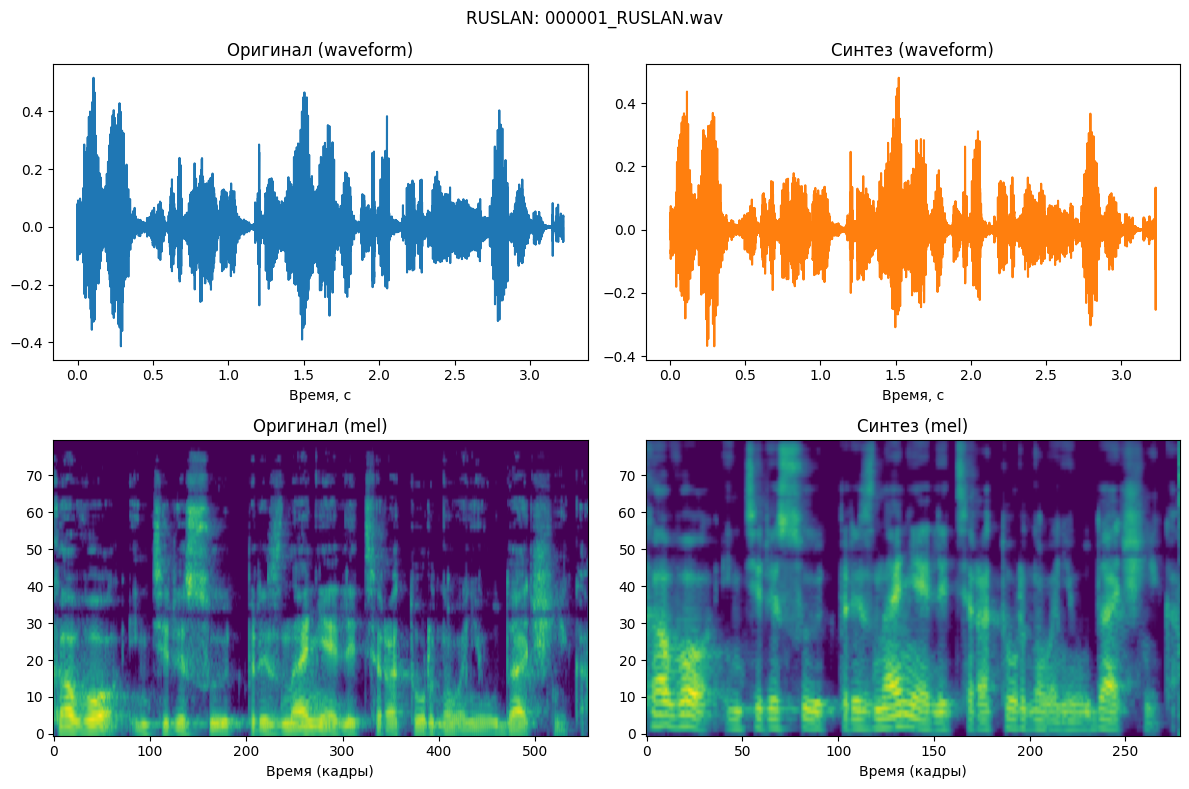

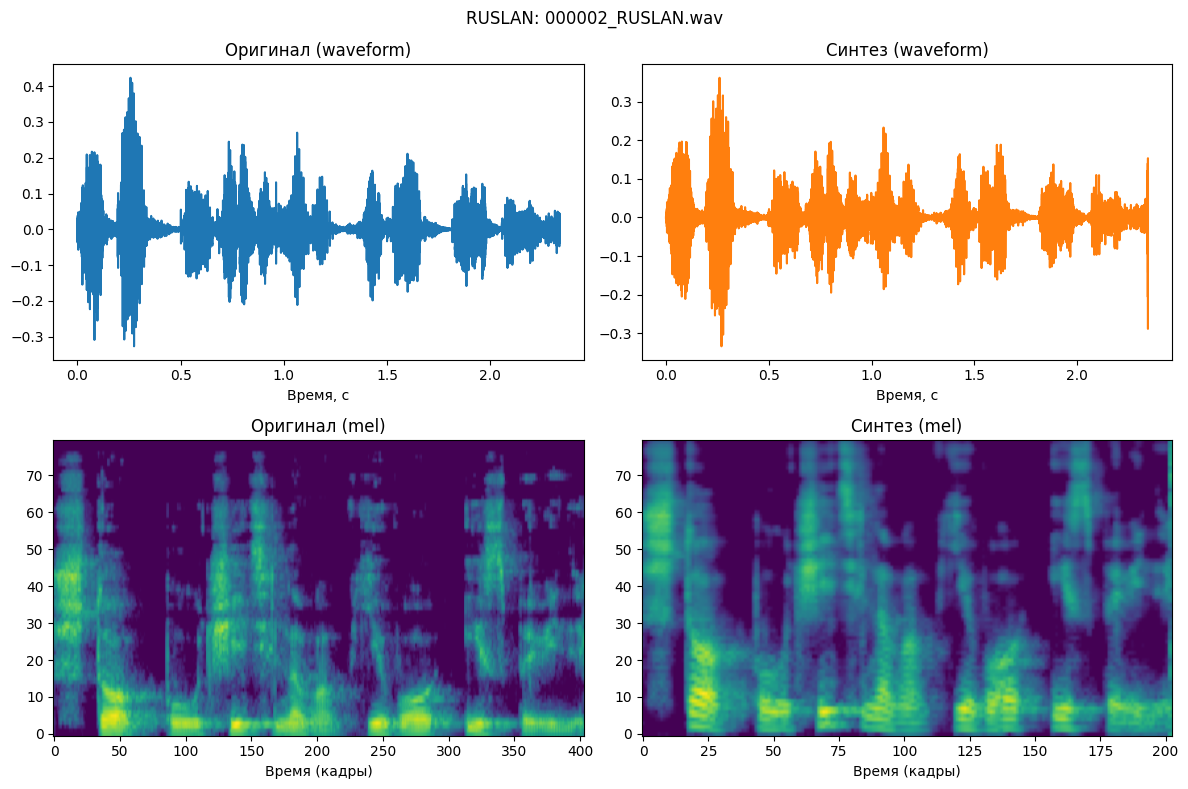

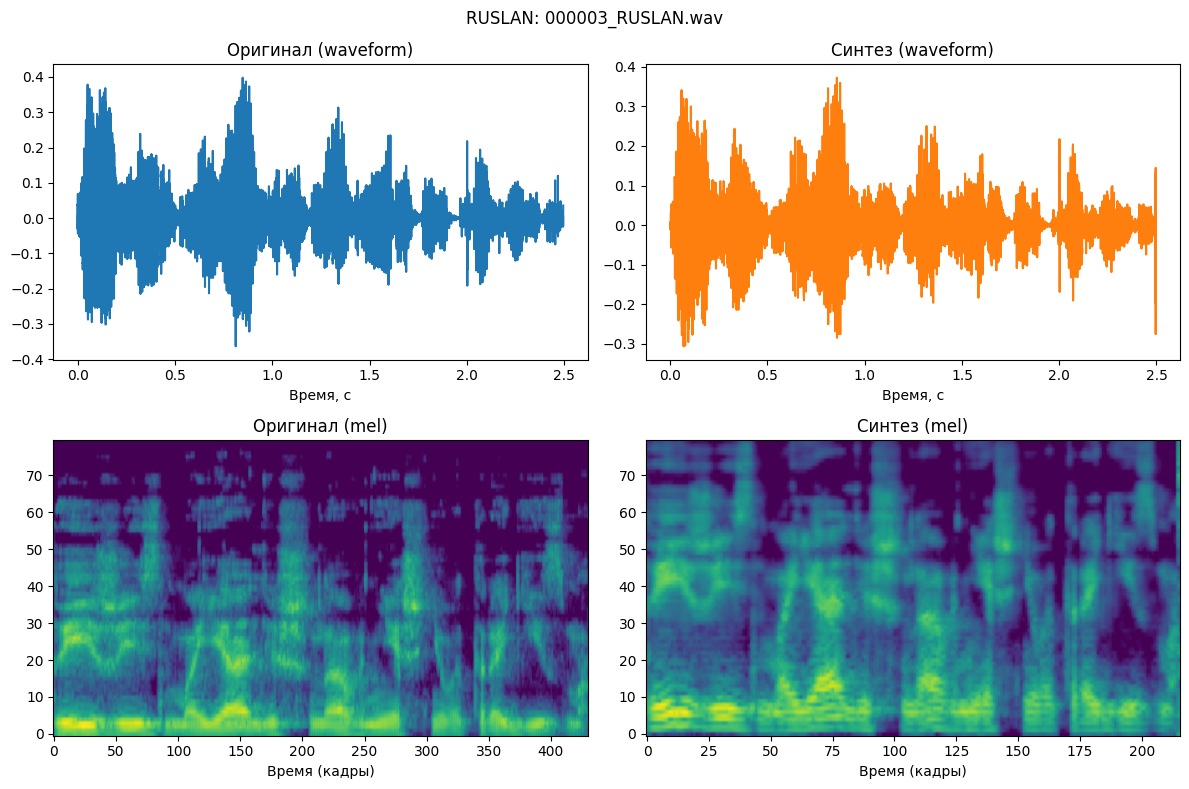

In [13]:
# 6.1 Анализ на обучающих данных (RUSLAN): сравнение оригинала и resynthesis
from src.transforms.mel_spectrogram import MelSpectrogram, MelSpectrogramConfig

# конфиг мел-спек
mel_config = MelSpectrogramConfig(
    sr=22050, win_length=1024, hop_length=256, n_fft=1024,
    f_min=0, f_max=11025, n_mels=80
)
mel_fn = MelSpectrogram(mel_config)

project_root = Path.cwd()
orig_dir = project_root / "data" / "datasets" / "ruslan" / "audio"
synth_dir = project_root / "out_demo_ruslan"
pairs = []
for orig in sorted(orig_dir.glob("*.wav"))[:3]:
    synth = synth_dir / f"{orig.stem}_synthesized.wav"
    if synth.exists():
        pairs.append((orig, synth))

for orig_path, synth_path in pairs:
    x, sr = load_audio(orig_path)
    y, sr2 = load_audio(synth_path)
    x_t = torch.from_numpy(x).float()
    y_t = torch.from_numpy(y).float()
    if x_t.dim() == 1:
        x_t = x_t.unsqueeze(0)
    if y_t.dim() == 1:
        y_t = y_t.unsqueeze(0)
    mel_orig = mel_fn(x_t).squeeze(0).numpy()
    mel_synth = mel_fn(y_t).squeeze(0).numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    t_orig = np.arange(x.size) / sr
    t_synth = np.arange(y.size) / sr2
    axes[0, 0].plot(t_orig, x.squeeze(), color="C0")
    axes[0, 0].set_title("Оригинал (waveform)")
    axes[0, 0].set_xlabel("Время, с")
    axes[0, 1].plot(t_synth, y.squeeze(), color="C1")
    axes[0, 1].set_title("Синтез (waveform)")
    axes[0, 1].set_xlabel("Время, с")
    axes[1, 0].imshow(mel_orig, aspect="auto", origin="lower")
    axes[1, 0].set_title("Оригинал (mel)")
    axes[1, 0].set_xlabel("Время (кадры)")
    axes[1, 1].imshow(mel_synth, aspect="auto", origin="lower")
    axes[1, 1].set_title("Синтез (mel)")
    axes[1, 1].set_xlabel("Время (кадры)")
    plt.suptitle(f"RUSLAN: {orig_path.name}")
    plt.tight_layout()
    plt.show()

**Вопросы по анализу на обучающих данных (RUSLAN):**
1. Какие различия вы видите между оригиналом и синтезом? \
Видно, что мел-спектрограммы очень похожи, но сгенерированные немного размыты, поэтому качество аудио хуже оригинала. Из-за этой нечеткости появляются шумы и артефакты. Также на сгенерированных waveform на конце присутствует пик.
2. Можно ли на слух понять, что аудио синтезировано? \
Из-за робовоиса это возможно. Чем выше частота спикера, тем его больше.
3. Можно ли это определить по форме волны или спектрограмме? \
Да, мел-спектрограмма сгенерированного аудио визуально размыта.
4. Какие выводы вы можете сделать? \
Для относительно короткого времени обучения и всего 15 млн параметров у модели, качество генерации хорошее.

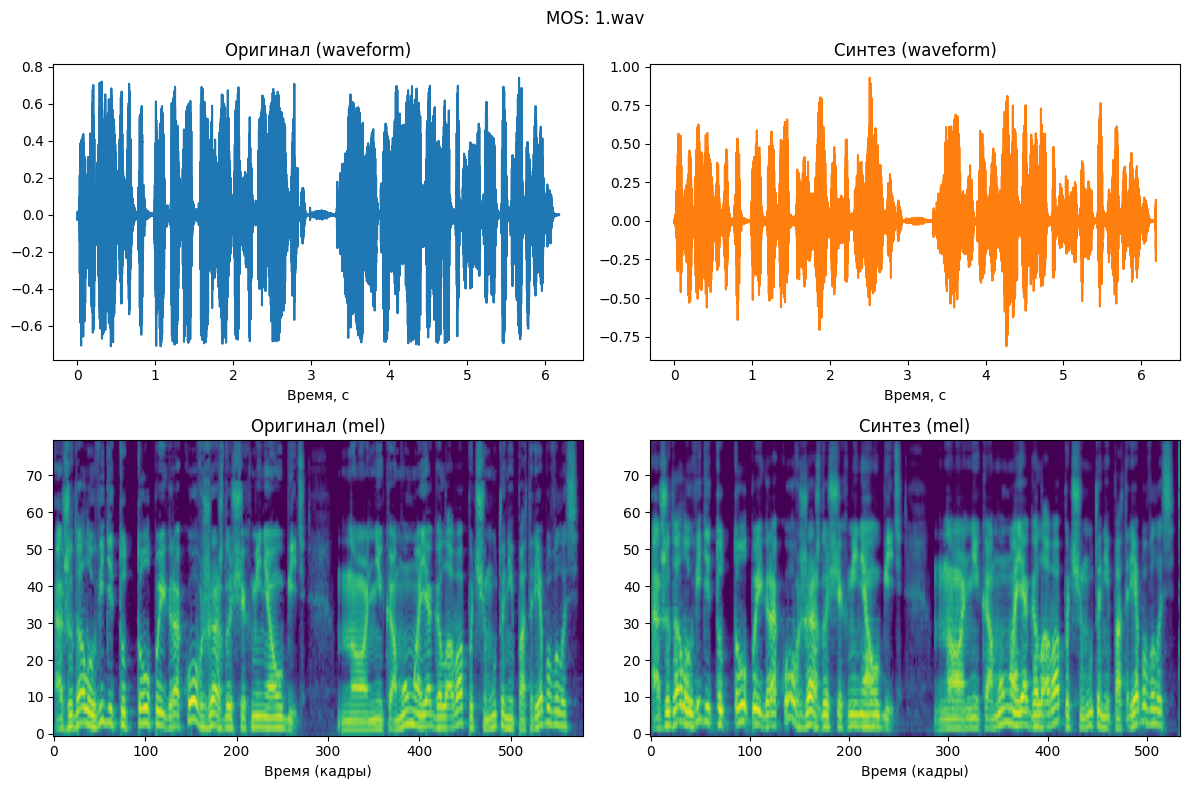

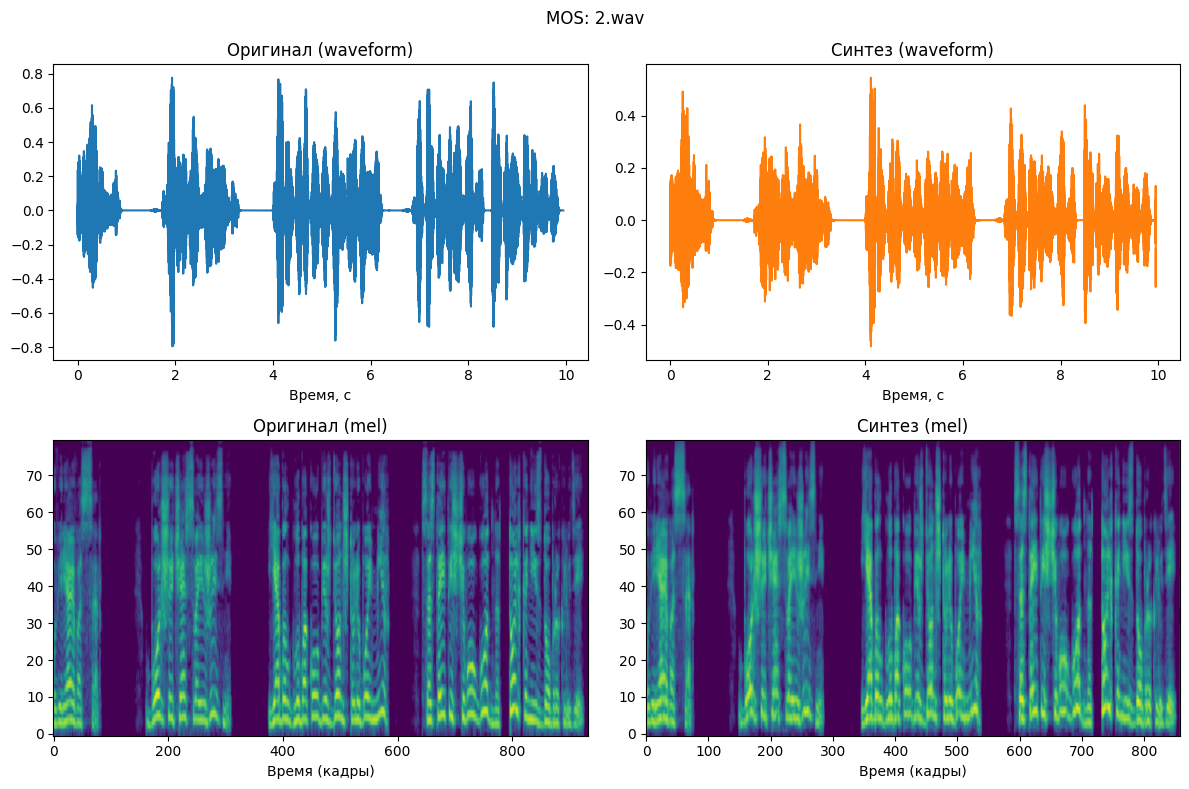

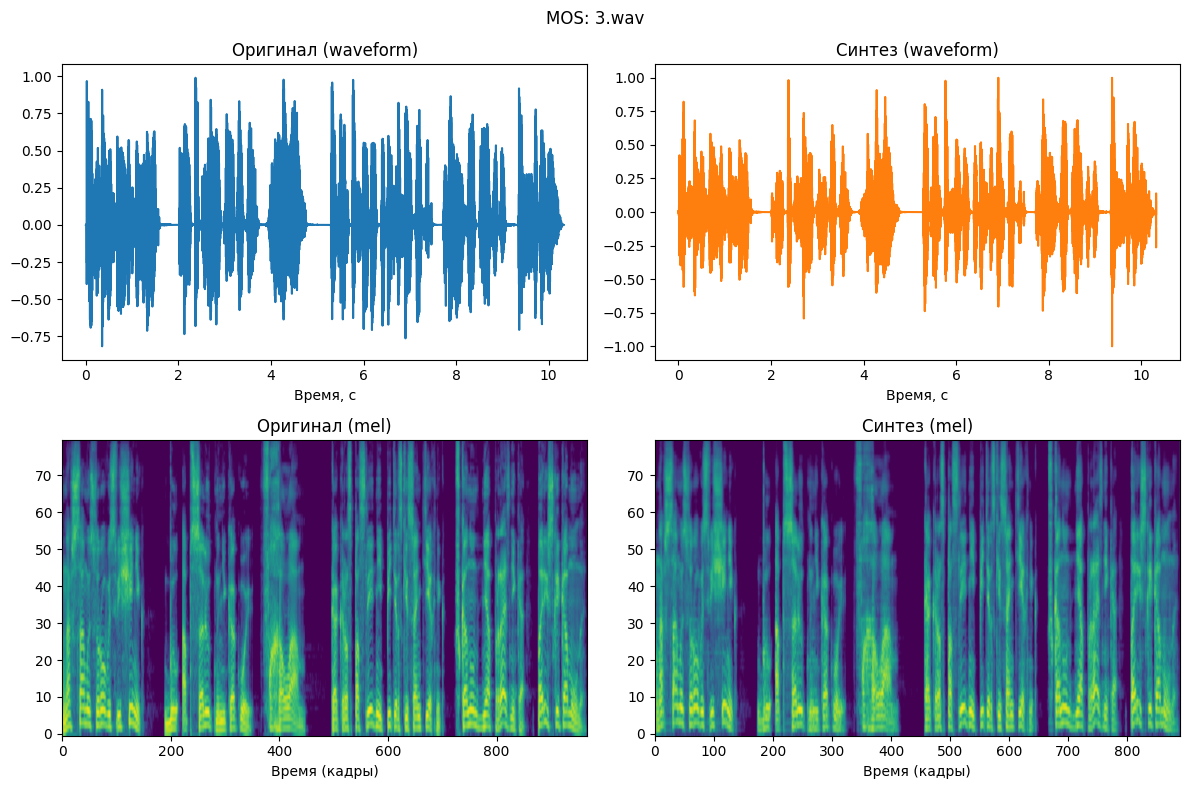

In [14]:
# 6.2 Анализ на внешних данных (MOS): сравнение оригинала и синтеза
orig_dir = Path("data/mos/audio")
synth_dir = Path("out_demo_mos")

for orig_path in sorted(orig_dir.glob("*.wav")):
    synth_path = synth_dir / f"{orig_path.stem}_synthesized.wav"
    if not synth_path.exists():
        continue
    x, sr = load_audio(orig_path)
    y, sr2 = load_audio(synth_path)
    x_t = torch.from_numpy(x).float()
    y_t = torch.from_numpy(y).float()
    if x_t.dim() == 1:
        x_t = x_t.unsqueeze(0)
    if y_t.dim() == 1:
        y_t = y_t.unsqueeze(0)
    mel_orig = mel_fn(x_t).squeeze(0).numpy()
    mel_synth = mel_fn(y_t).squeeze(0).numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    t_orig = np.arange(x.size) / sr
    t_synth = np.arange(y.size) / sr2
    axes[0, 0].plot(t_orig, x.squeeze(), color="C0")
    axes[0, 0].set_title("Оригинал (waveform)")
    axes[0, 0].set_xlabel("Время, с")
    axes[0, 1].plot(t_synth, y.squeeze(), color="C1")
    axes[0, 1].set_title("Синтез (waveform)")
    axes[0, 1].set_xlabel("Время, с")
    axes[1, 0].imshow(mel_orig, aspect="auto", origin="lower")
    axes[1, 0].set_title("Оригинал (mel)")
    axes[1, 0].set_xlabel("Время (кадры)")
    axes[1, 1].imshow(mel_synth, aspect="auto", origin="lower")
    axes[1, 1].set_title("Синтез (mel)")
    axes[1, 1].set_xlabel("Время (кадры)")
    plt.suptitle(f"MOS: {orig_path.name}")
    plt.tight_layout()
    plt.show()

**Вопросы по анализу на внешних данных (MOS):**
1. Справедливы ли выводы из анализа на обучающих данных? \
В целом, да, но MOS аудиозаписи длиннее, поэтому мел-спектрограмма плотнее и размытость видно хуже.
2. Какие различия вы видите между обучающим (RUSLAN) и внешним (MOS) датасетами? \
На спектрограмме MOS аудиозаписей видно более ярко выраженные паузы в речи, больше деталей. Наверное, эти аудио записаны на более качественный микрофон.
3. Объясните причины различий, если они есть. \
Качество генерации очень похожее. На 2 аудио из MOS, где спикер говорит на более высоких частотах, чем спикер из обучаемых данных, робовоис довольно сильный. Полагаю, модель плохо выучила высокие частоты из-за отсутствия подобных примеров в обучаемых данных.